# Lab: Relationships Between Categorical Features

A fictional telecommunications company wants to understand which customer groups had the greatest observed churn percentages. A customer **churned** if they left the company during the previous month.

You will use the reproducible analysis workflow:

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can help answer it?
3. **Operation:** What should the code select, calculate, or compare?
4. **Check:** Does the result have the expected rows, columns, units, and possible values?
5. **Evidence:** Which result directly answers the question?
6. **Conclusion:** What claim is supported?
7. **Limitation:** What should we avoid concluding?


## Learning goals

By the end of this lab, you should be able to:

- identify a target feature;
- describe the distribution of a categorical target;
- create count, joint-percentage, and conditional-percentage cross-tabs;
- choose a normalization direction from the question;
- check the denominator represented by a percentage;
- refine the visual design of a categorical comparison; and
- distinguish an observed relationship from a causal claim.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook's output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

Each row represents one customer in IBM's fictional telecommunications sample.

| Feature | Feature type | Description |
| --- | --- | --- |
| `customer_id` | Identifier | Anonymous customer identifier |
| `contract` | Categorical | Month-to-month, one-year, or two-year contract |
| `internet_service` | Categorical | DSL, fiber optic, or no internet service |
| `tech_support` | Categorical | Technical-support status |
| `payment_method` | Categorical | Customer's payment method |
| `paperless_billing` | Categorical | Whether the customer uses paperless billing |
| `churn` | Categorical target | Whether the customer left during the previous month |

The file contains 7,043 customers and no missing values in these fields. See `data/README.md` for provenance and preparation.


## Prepare the notebook

Import Pandas using its conventional alias `pd` and Matplotlib's `pyplot` component using its conventional alias `plt`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Read the data

Read `data/telco_customer_churn.csv` into a DataFrame named `customers`.


In [2]:
customers = pd.read_csv("data/telco_customer_churn.csv")

## Check the data

Display the first five rows.


In [3]:
customers.head()

,customer_id,contract,internet_service,tech_support,payment_method,paperless_billing,churn
0,7590-VHVEG,Month-to-month,DSL,No,Electronic check,Yes,No
1,5575-GNVDE,One year,DSL,No,Mailed check,No,No
2,3668-QPYBK,Month-to-month,DSL,No,Mailed check,Yes,Yes
3,7795-CFOCW,One year,DSL,Yes,Bank transfer (automatic),No,No
4,9237-HQITU,Month-to-month,Fiber optic,No,Electronic check,Yes,Yes


## Check the features

Display a summary that includes the feature names, non-missing counts, and Pandas data storage types.


In [4]:
customers.info()

missing_values = customers.isna().sum()
missing_values

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   customer_id        7043 non-null   str  
 1   contract           7043 non-null   str  
 2   internet_service   7043 non-null   str  
 3   tech_support       7043 non-null   str  
 4   payment_method     7043 non-null   str  
 5   paperless_billing  7043 non-null   str  
 6   churn              7043 non-null   str  
dtypes: str(7)
memory usage: 777.4 KB


customer_id          0
contract             0
internet_service     0
tech_support         0
payment_method       0
paperless_billing    0
churn                0
dtype: int64

A **categorical** feature places observations into groups or labels. A **quantitative** feature records a numerical amount or measurement for which arithmetic is meaningful.


**Complete the table using the results above.** In the data type column, classify each feature as categorical or quantitative. In the data storage type column, record the type reported by Pandas. Different Pandas versions may display text as `str` or `object`.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `customer_id` | Categorical | str | 0 |
| `contract` | Categorical | str | 0 |
| `internet_service` | Categorical | str | 0 |
| `tech_support` | Categorical | str | 0 |
| `payment_method` | Categorical | str | 0 |
| `paperless_billing` | Categorical | str | 0 |
| `churn` | Categorical | str | 0 |


## Identify the target


**Which feature is the target, and what outcome does it represent?**

Your answer: The target feature is churn. It represents whether a customer left the company during the previous month.


## Describe the target distribution with counts

Create and display a Series named `churn_counts`.


In [5]:
churn_counts = customers["churn"].value_counts()
churn_counts

churn
No     5174
Yes    1869
Name: count, dtype: int64

**Which target outcome is more frequent?**

Your answer: The No outcome is more frequent. There are 5,174 customers who did not churn compared with 1,869 customers who did churn.


## Describe the target distribution with relative frequencies

Create and display a Series named `churn_percent`.


In [6]:
churn_percent = customers["churn"].value_counts(normalize=True) * 100
churn_percent

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**What percentage of all customers churned?**

Your answer: About 26.54% of all customers churned.


# Analysis 1: Is churn related to contract type?

Follow the analysis workflow from question through limitation.


**Before calculating a cross-tab, which contract type do you predict had the greatest churn percentage? Explain your prediction.**

Your answer: I predict that customers with month-to-month contracts had the highest churn percentage because they are not committed to a long term contract, so it may be easier for them to leave the company.


## Step 1: Question


The question is: **Is churn related to contract type?**


## Step 2: Data

The relevant features are `contract` and `churn`. Before calculating percentages, compare the raw counts in their joint distribution.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.


In [7]:
contract_churn_counts = pd.crosstab(
    customers["contract"],
    customers["churn"]
)

contract_churn_counts

churn,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


**Which contract type has the greatest raw number of customers who churned?**

Your answer: Month to month contracts had the greatest raw number of customers who churned, with 1,655 customers.


**Do the raw churn counts establish which contract group was most likely to churn? Explain.**

Your answer: No. The raw churn counts do not show which contract group was most likely to churn because the contract groups have different numbers of customers. We need to compare the churn percentage within each contract type instead.


## Step 3: Operation

To compare likelihood fairly, calculate churn percentages within each contract type. First inspect the group totals.

Recreate the contract/churn cross-tab using `margins=True`.


In [8]:
contract_churn_totals = pd.crosstab(
    customers["contract"],
    customers["churn"],
    margins=True
)

contract_churn_totals

churn,No,Yes,All
contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043


**Why do the contract-group totals matter when comparing likelihood?**

Your answer: The contract group totals matter because the groups are different sizes. Comparing only the number of customers who churned could be misleading, so using percentages within each contract type gives a fairer comparison.

### Joint percentages

Create and display `contract_joint_percent`. All cells together should add to 100%.


In [9]:
contract_joint_percent = pd.crosstab(
    customers["contract"],
    customers["churn"],
    normalize=True
) * 100

contract_joint_percent

churn,No,Yes
contract,,
Month-to-month,31.520659,23.498509
One year,18.557433,2.356950
Two year,23.384921,0.681528


## Step 4: Check

Display the sum of every value in `contract_joint_percent`.


In [10]:
contract_joint_percent.to_numpy().sum()

np.float64(100.00000000000001)

**What denominator does each joint percentage use?**

Your answer: Each joint percentage uses the total number of customers, 7,043, as the denominator.


**Does the joint-percentage table directly answer which contract group was most likely to churn?**

Your answer: No. The joint percentage table shows each contract and churn combination as a percentage of all customers, not the churn percentage within each contract group. To compare which contract type was most likely to churn, we need conditional percentages within each contract type.

### Conditional percentages

Create `churn_within_contract` so each row describes churn outcomes within one contract type.


In [11]:
churn_within_contract = pd.crosstab(
    customers["contract"],
    customers["churn"],
    normalize="index"
) * 100

churn_within_contract

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Check the conditional percentages

Display the sum of each row in `churn_within_contract`.


In [12]:
churn_within_contract.sum(axis=1)


contract
Month-to-month    100.0
One year          100.0
Two year          100.0
dtype: float64

**What should every row add to, and why?**

Your answer: Every row should add to 100% because each row represents all churn outcomes within one contract type.


**Which contract group had the greatest observed churn percentage? Report the percentage.**

Your answer: Customers with month to month contracts had the greatest observed churn percentage at about 42.71%.


**Was your prediction supported?**

Your answer: Yes. My prediction was supported because customers with month to month contracts had the highest observed churn percentage at about 42.71%.


## Step 5: Evidence

### Visualize the raw counts

Make a stacked bar chart from `contract_churn_counts`.


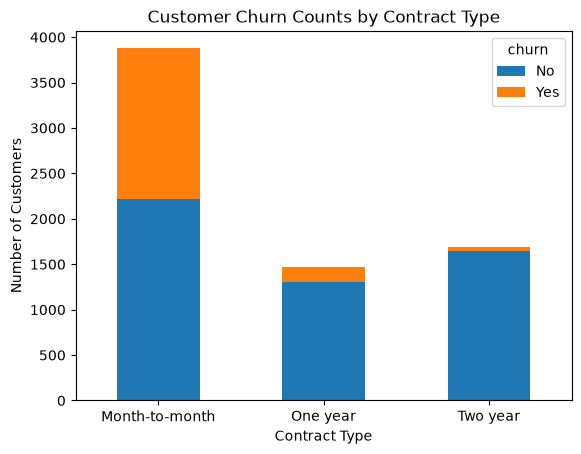

In [13]:
contract_churn_counts.plot(
    kind="bar",
    stacked=True
)

plt.title("Customer Churn Counts by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()


### Visualize the conditional percentages

Make a 100% stacked bar chart from `churn_within_contract`. Use:

- `"lightgray"` for customers who did not churn;
- `"steelblue"` for customers who churned;
- a question-focused title;
- descriptive axis labels;
- horizontal x-axis labels; and
- an audience-friendly legend.


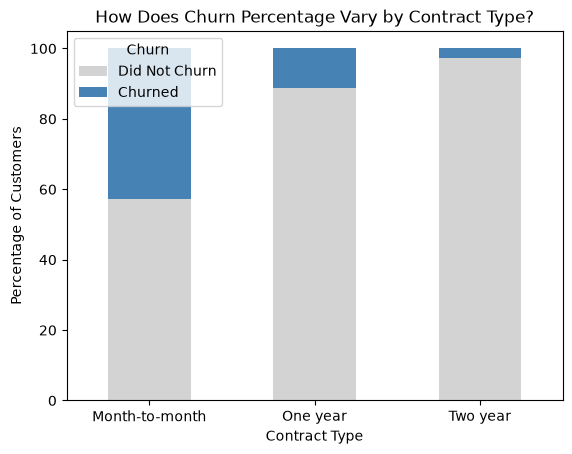

In [14]:
churn_within_contract.plot(
    kind="bar",
    stacked=True,
    color=["lightgray", "steelblue"]
)

plt.title("How Does Churn Percentage Vary by Contract Type?")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(["Did Not Churn", "Churned"], title="Churn")
plt.show()

**Which chart answers the likelihood question more clearly: counts or conditional percentages? Explain.**

Your answer: The conditional percentage chart answers the likelihood question more clearly because it compares the churn rate within each contract type. The raw count chart can be misleading because the contract groups have different numbers of customers.


## Step 6: Conclusion


**What conclusion about contract type and churn is supported by this sample?**

Your answer: In this sample, churn was associated with contract type. Customers with month-to-month contracts had the highest observed churn percentage at about 42.71%, compared with about 11.27% for one year contracts and 2.83% for two year contracts.


## Step 7: Limitation


**Why does this analysis not prove that changing a customer's contract would cause a change in churn?**

Your answer: This analysis only shows an observed relationship between contract type and churn. It does not prove that changing a customer's contract would cause their churn behavior to change because other factors could also affect whether a customer leaves.


# Analysis 2: Is churn related to payment method?

Apply the same workflow to a second pair of categorical features.


## Step 1: Question


The question is: **Is churn related to payment method?**


## Step 2: Data

Create and display the joint distribution of `payment_method` and `churn` as raw counts. Name it `payment_churn_counts`.

Create and display `payment_churn_counts`.


In [15]:
payment_churn_counts = pd.crosstab(
    customers["payment_method"],
    customers["churn"]
)

payment_churn_counts

churn,No,Yes
payment_method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


## Step 3: Operation

Create and display `churn_within_payment`.


In [16]:
churn_within_payment = pd.crosstab(
    customers["payment_method"],
    customers["churn"],
    normalize="index"
) * 100

churn_within_payment

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Step 4: Check

Display the sum of every row in `churn_within_payment`.


In [17]:
churn_within_payment.sum(axis=1)

payment_method
Bank transfer (automatic)    100.0
Credit card (automatic)      100.0
Electronic check             100.0
Mailed check                 100.0
dtype: float64

**Which payment-method group had the greatest observed churn percentage? Report the percentage.**

Your answer: Customers who used electronic check had the greatest observed churn percentage at about 45.29%.


## Step 5: Evidence

Make a 100% stacked bar chart. Choose two readable colors that are different from the `"lightgray"` and `"steelblue"` used in the contract chart. Use the same color consistently for each outcome throughout this chart and include audience-friendly labels.


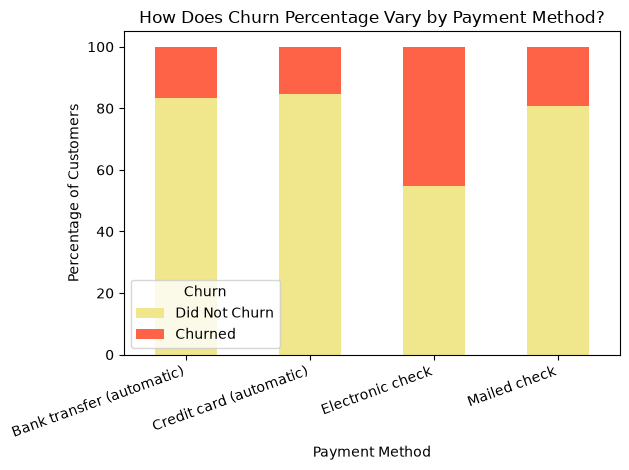

In [18]:
churn_within_payment.plot(
    kind="bar",
    stacked=True,
    color=["khaki", "tomato"]
)

plt.title("How Does Churn Percentage Vary by Payment Method?")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=20, ha="right")
plt.legend(["Did Not Churn", "Churned"], title="Churn")
plt.tight_layout()
plt.show()

## Step 6: Conclusion


**What conclusion about payment method and churn is supported by the sample? Include the percentage that provides your strongest evidence.**

Your answer: In this sample, churn was associated with payment method. Customers who used electronic check had the highest observed churn percentage at about 45.29%, which was higher than the churn percentages for the other payment methods.



## Step 7: Limitation


**Why does this analysis not prove that changing a customer's payment method would cause a change in churn?**

Your answer: This analysis only shows an observed relationship between payment method and churn. It does not prove that changing a customer's payment method would cause their churn behavior to change because other factors could also influence whether a customer leaves.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that you did not use one.

Your answer: I used AI to help me understand some of the code and double check my answers. One thing I checked was how to compare the churn percentages between each group. I used the suggestion after making sure the results matched what my notebook showed.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Keep code, figures, and written answers neat and easy to read.
- Distinguish an observed relationship from a causal claim.
- Complete the AI-use reflection.
- Submit the completed notebook by the deadline.
